# A simple configurable corpus model

This executable example builds the smallest useful variable-size corpus: at most three media channels and two observed controls. Every active channel directly affects sales. Controls affect sales through the baseline only; they never alter channel nodes. One latent demand slot is present but deliberately isolated, so this is not a confounding example.

The easy and difficult variants use the same graph and mechanism family. They differ only in the sales random-walk noise prior.

In [1]:
import os
import shutil
import tempfile
import warnings

warnings.filterwarnings('ignore', message='IProgress not found')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import Image, display

from pymc_marketing.mmm import GeometricAdstock, MichaelisMentenSaturation, MMM

import prior_generator as pg
from prior_generator import viz
from prior_generator.data_generator import DataGenerator
from prior_generator.slots import SlotLayout
from prior_generator.sampler import ADSTOCK_FAMILY_KEYS, SATURATION_FAMILY_KEYS
print('prior-generator', pg.__version__)

prior-generator 0.0.1


## Fixed maximum layout and exact graph budget

Active counts are sampled per cell, then inactive trailing slots are zero padded. All eight edge budgets are explicit, so no omitted Bernoulli default can add an edge. The maximum exact `zb` budget clamps to the eligible active controls, so each one affects the baseline. The zero `zc` budget forbids every control-to-channel edge.

Family configuration uses canonical names, so it is self-describing rather than positional. The unchanged corpus schema intentionally does not persist `sat_family`; the full single-world audit below exposes both selected mechanism families.

Here `easy` means an estimable design, not merely a smooth line: 156 weeks, nine eight-week zero-spend interventions, one-lag geometric adstock (therefore no hidden carryover), and a nearly constant intrinsic baseline. The easy and difficult variants still differ only in their sales-noise scale.

In [2]:
EDGE_BUDGET = {
    'cy': (3, 3), 'dc': (0, 0), 'dz': (0, 0), 'db': (0, 0),
    'zb': (2, 2), 'zc': (0, 0), 'cc': (0, 0), 'zz': (0, 0),
}
COMMON = dict(
    n_treatments=3, n_covariates=2, n_latent=1, T=156,
    l_max=1,
    n_treatments_active_range=(1, 3),
    n_covariates_active_range=(1, 2),
    n_latent_active_range=(1, 1),
    edge_budget=EDGE_BUDGET, n_cells=6, draws_per_cell=1, seed=20260726,
    adstock_family_probs={**dict.fromkeys(ADSTOCK_FAMILY_KEYS, 0.0), 'geometric': 1.0},
    saturation_family_probs={**dict.fromkeys(SATURATION_FAMILY_KEYS, 0.0), 'michaelis_menten': 1.0},
    confounding_strength_range=(0.0, 0.0),
    rw_baseline_std_sigma=0.005,
    n_channel_shocks=9, channel_shock_length_range=(8, 8),
)
easy_cfg = pg.make_scm_prior(**COMMON, rw_sales_std_sigma=0.03)
hard_cfg = pg.make_scm_prior(**COMMON, rw_sales_std_sigma=1.0)
assert easy_cfg.adstock_family_probs == {**dict.fromkeys(ADSTOCK_FAMILY_KEYS, 0.0), 'geometric': 1.0}
assert easy_cfg.saturation_family_probs == {**dict.fromkeys(SATURATION_FAMILY_KEYS, 0.0), 'michaelis_menten': 1.0}
print('layout slots:', easy_cfg.layout.n_slots, '| edge budget:', EDGE_BUDGET)

layout slots: 25 | edge budget: {'cy': (3, 3), 'dc': (0, 0), 'dz': (0, 0), 'db': (0, 0), 'zb': (2, 2), 'zc': (0, 0), 'cc': (0, 0), 'zz': (0, 0)}


## A full-size visual world

The corpus below uses `sample_prior_predictive` to vary active counts and pad inactive slots. For these visualizations only, `sample_scm` draws one world with all configured maximum-size nodes active: C1 through C3, Z1 through Z2, and the isolated D1 node. Its graph still has no D1 edges, each control has only a Z to B path, and every channel has geometric adstock and Michaelis-Menten saturation.

In [3]:
world = pg.sample_scm(easy_cfg, seed=5)
assert world.K == 3 and world.M == 2 and world.J == 1
assert not world.g['g_dc'].any() and not world.g['g_dz'].any() and not world.g['g_db'].any()
assert world.g['g_cy'].all() and world.g['g_zb'].all()
assert not world.g['g_zc'].any() and not world.g['g_cc'].any() and not world.g['g_zz'].any()
shock_channels = set(np.asarray(world.params['channel_shock']['channel'], dtype=int))
assert shock_channels == set(range(world.K))
print('visual world:', f'T={world.T}, K={world.K}, M={world.M}, J={world.J}')
print('D1 is isolated; Z1/Z2 affect only the baseline, never C1/C2/C3.')

visual world: T=156, K=3, M=2, J=1
D1 is isolated; Z1/Z2 affect only the baseline, never C1/C2/C3.


## Structural-equation audit

`sample_scm` records this world as an acyclic Pearl SCM over vector-valued nodes. The vectors span the full generated horizon; this does not assert a Markov property over time. `world.equations` gives the executed vector equations, while `world.equation_parameters` gives their realized coefficients and mechanism choices. With `rho = 0`, the recorded exogenous vectors are independent. Exact replay requires both the realized equation parameters and the recorded exogenous innovations.

In [4]:
equations = world.equations
equation_parameters = world.equation_parameters
exogenous = world.exogenous
T_full = world.T + world.cfg.adstock_burn_in
audit_nodes = ('D1', 'Z1', 'Z2', 'C1', 'C2', 'C3', 'B', 'Y')
assert set(audit_nodes) <= equations.keys()
assert set(audit_nodes) <= equation_parameters.keys()
for node in audit_nodes:
    print(f'\n{node}: {equations[node]}')
    print('parameters:', equation_parameters[node])

def family_from_audit(parameters, mechanism):
    family_keys = (f'{mechanism}_family', 'sat_family', mechanism) if mechanism == 'saturation' else ('adstock_family', mechanism)
    for key in family_keys:
        if key in parameters:
            value = parameters[key]
            return value['family'] if isinstance(value, dict) else value
    for value in parameters.values():
        if isinstance(value, dict):
            try:
                return family_from_audit(value, mechanism)
            except AssertionError:
                pass
    raise AssertionError(f'{mechanism} family is missing from the public audit')

for channel in ('C1', 'C2', 'C3'):
    assert family_from_audit(equation_parameters[channel], 'adstock') == 'geometric'
    assert family_from_audit(equation_parameters[channel], 'saturation') == 'michaelis_menten'
assert easy_cfg.confounding_strength_range == (0.0, 0.0)

expected_exogenous_shapes = {
    'eps_d': (T_full, world.J), 'eps_z': (T_full, world.M),
    'eps_c': (T_full, world.K), 'eps_b': (T_full,), 'eps_y': (T_full,),
    'eps_c_hf': (T_full, world.K), 'eps_c_pulse': (T_full, world.K),
}
exogenous_shapes = {name: values.shape for name, values in exogenous.items()}
assert exogenous_shapes == expected_exogenous_shapes
print('\nfull-horizon exogenous shapes:', exogenous_shapes)
print('Exact replay needs these innovations together with the realized equation parameters.')


D1: D1_full = RW_full(eps_d[:, 0], rw_d[0]); D1 = D1_full[burn_in:]
parameters: {'random_walk': {'mean': 0.32567767272870873, 'std': 1.5998989960088155, 'smoothness': 0.9008346605552452, 'positive_only': False}}

Z1: Z1_full = RW_full(eps_z[:, 0], rw_z[0]); Z1 = Z1_full[burn_in:]
parameters: {'random_walk': {'mean': 0.7236077585279297, 'std': 0.7782630714291872, 'smoothness': 0.9435276924347725, 'positive_only': False}}

Z2: Z2_full = RW_full(eps_z[:, 1], rw_z[1]); Z2 = Z2_full[burn_in:]
parameters: {'random_walk': {'mean': -0.1764359805965212, 'std': 0.17704812144473617, 'smoothness': 0.3390648146531886, 'positive_only': False}}

C1: use_hf[0]=True; use_pulse[0]=True; own_C1_full = RW_full(eps_c_eff[:, 0], rw_c[0]) + hf_sigma[0] * eps_c_hf[:, 0] + pulse_amp[0] * eps_c_pulse[:, 0]; C1_unshocked_full = softplus(own_C1_full); C1_full = clamp_shock_1(softplus(own_C1_full)); C1 = C1_full[burn_in:]
parameters: {'random_walk': {'mean': 0.9202281218285849, 'std': 0.9955830156948388, 'smoothn

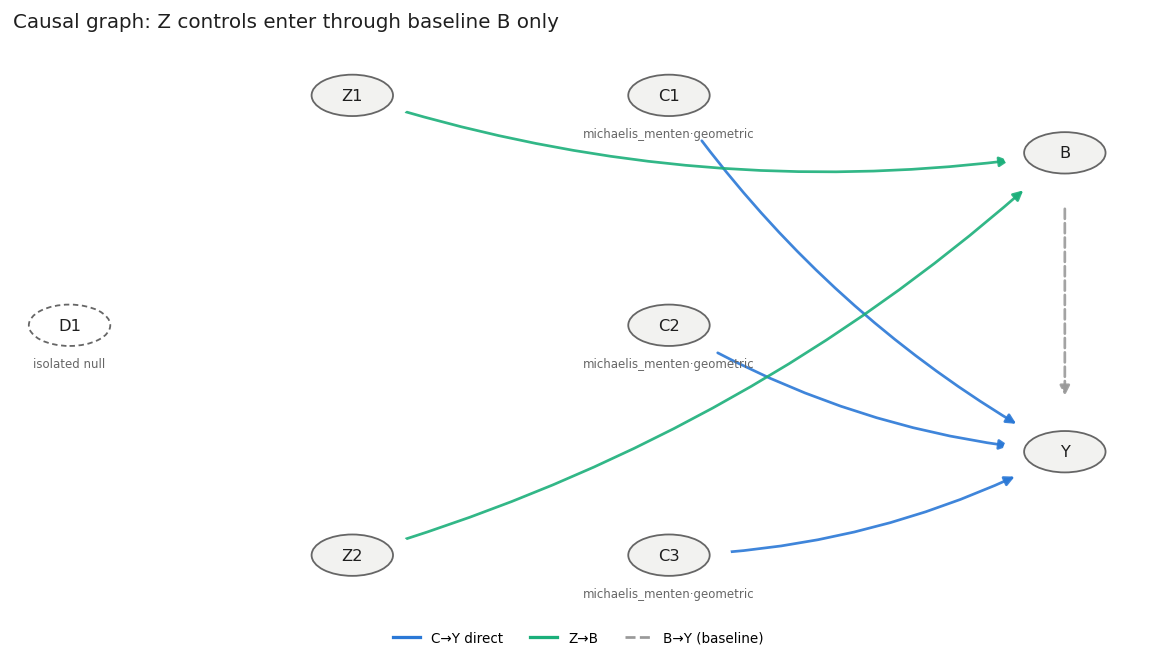

In [5]:
def show_fig(plot_fn, title):
    path = os.path.join(tempfile.mkdtemp(), 'fig.png')
    plot_fn(world, path, title)
    display(Image(filename=path))

show_fig(viz.plot_dag, 'Causal graph: Z controls enter through baseline B only')

The next graph is the PyMC **generative** model built from this world's recorded graph and structural choices. It is not the posterior oracle. The dependency view is curated to the main generated outputs so the graph remains readable; PyMC includes their upstream random variables automatically.

generative model variables shown: demand, controls, channels, baseline, contributions, sales


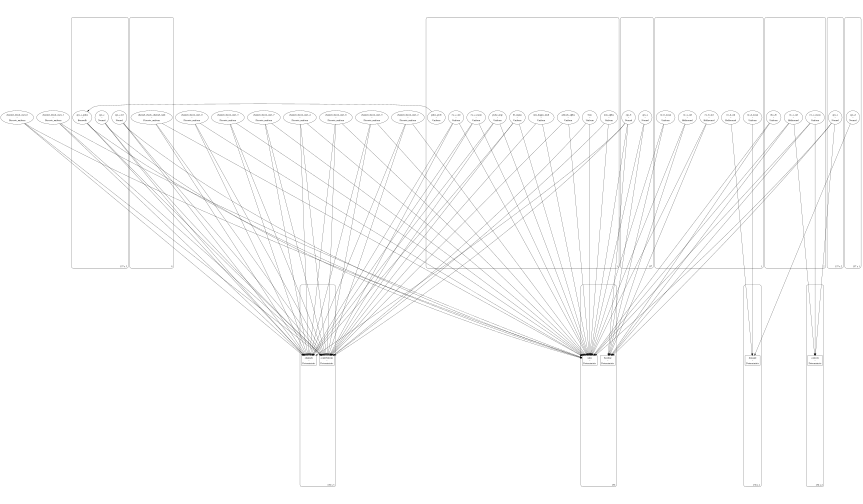

In [6]:
try:
    import graphviz
except ImportError as exc:
    raise RuntimeError('Install the docs extra to render this model graph.') from exc
if shutil.which('dot') is None:
    raise RuntimeError('Install the system Graphviz package to render this model graph.')

model, _, _ = pg.build_world_model(
    world.g, world.cfg, world.extras['structural'], world.T,
    prior_cond=world.extras.get('prior_cond'),
)
var_names = ['demand', 'controls', 'channels', 'baseline', 'contributions', 'sales']
available = [name for name in var_names if name in model.named_vars]
print('generative model variables shown:', ', '.join(available))
model_graph = pm.model_to_graphviz(model, var_names=available)
model_graph.graph_attr.update(size='12,7!', ratio='fill')
display(model_graph)

The generated time-series plot shows spend, observed controls, latent demand, and sales. D1 is displayed for auditing even though it is hidden and isolated. The channel plot compares each channel's spend with its true geometric-adstocked, Michaelis-Menten-saturated effect. The final plot shows the exact decomposition, whose reconstruction is verified numerically.

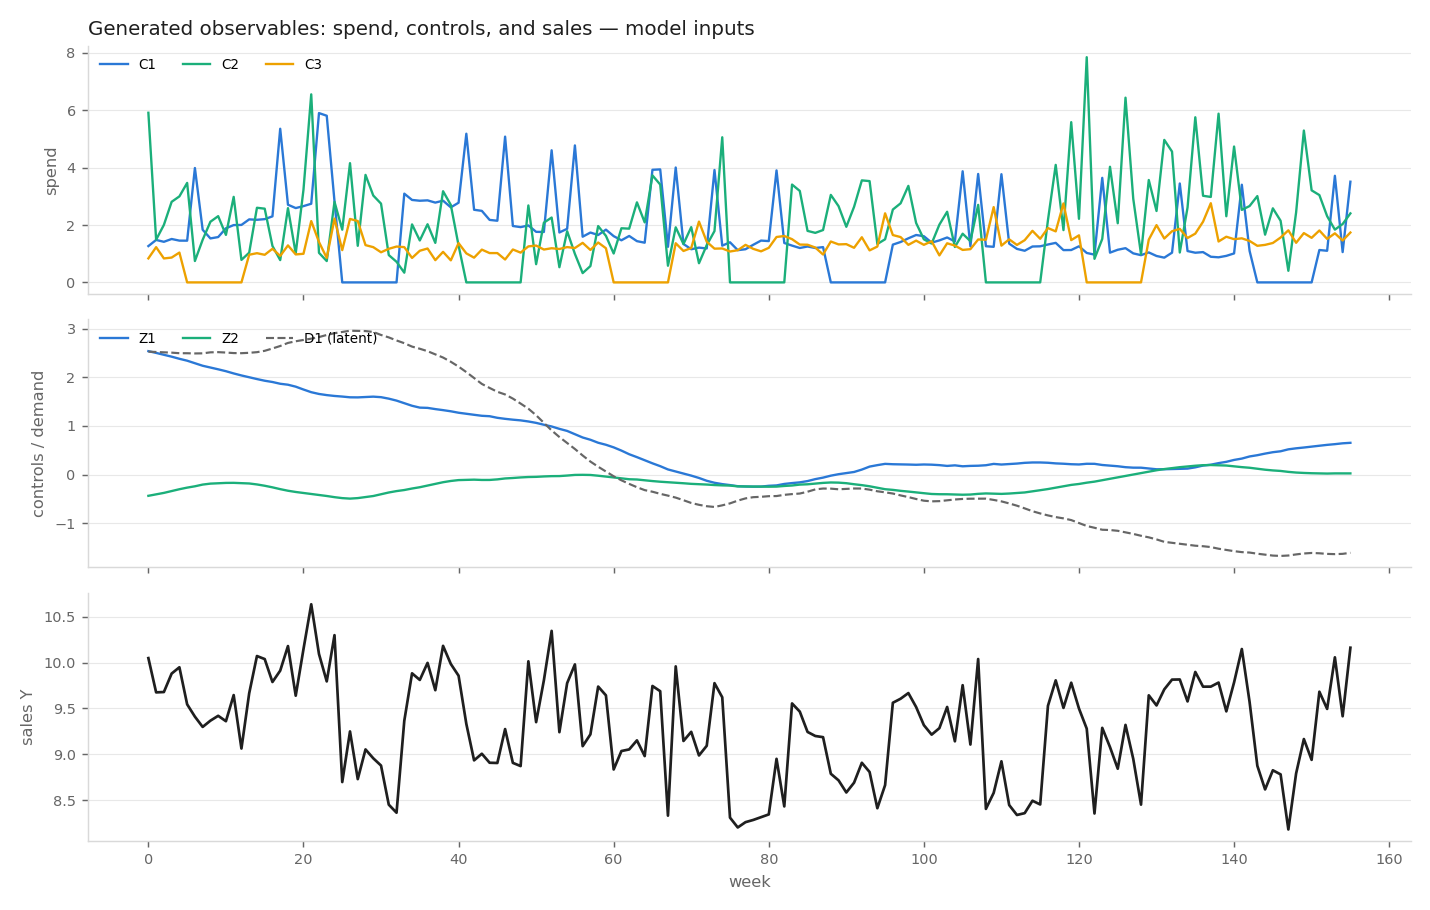

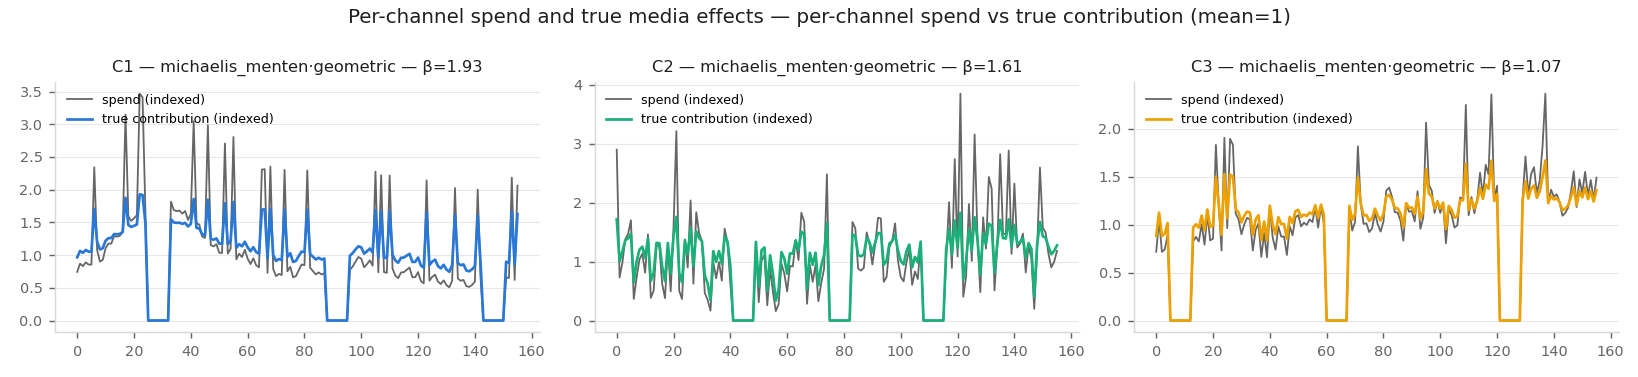

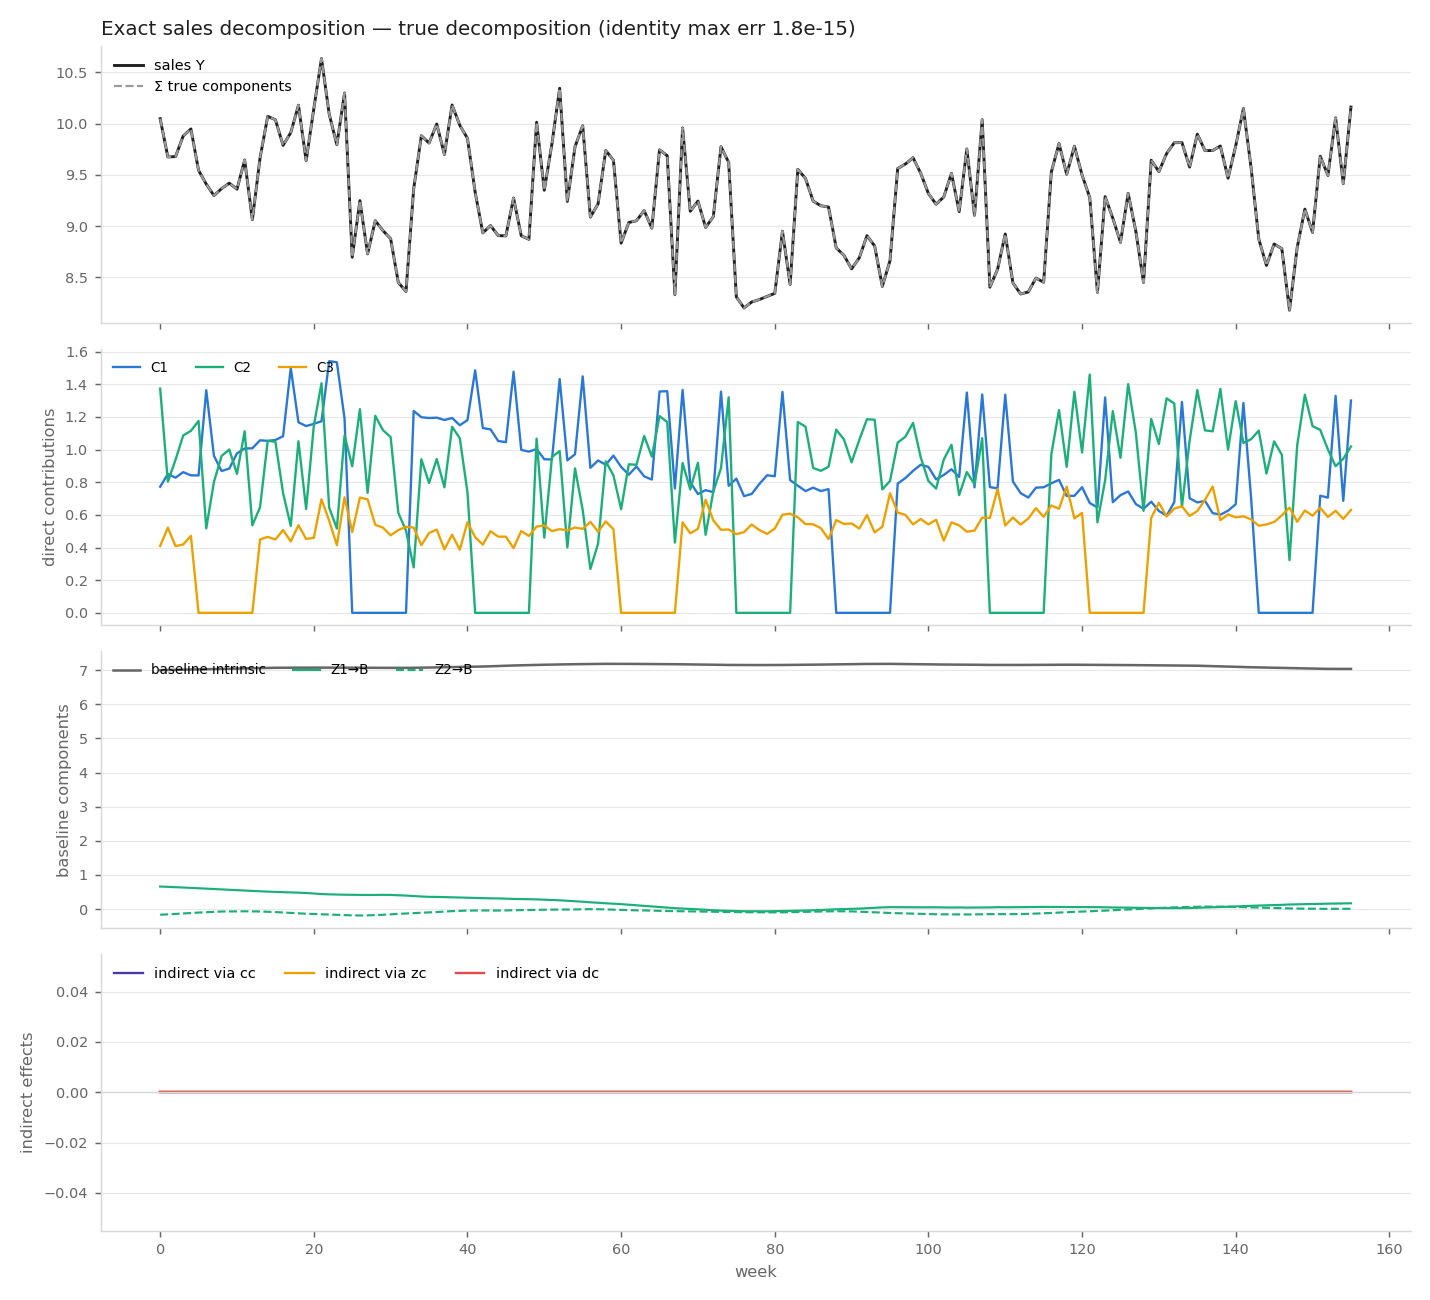

world reconstruction max abs error: 1.78e-15


In [7]:
show_fig(viz.plot_timeseries, 'Generated observables: spend, controls, and sales')
show_fig(viz.plot_channels, 'Per-channel spend and true media effects')
show_fig(viz.plot_decomposition, 'Exact sales decomposition')
print('world reconstruction max abs error:', f'{world.identity_error():.2e}')

## Test effect recovery with a regular PyMC-Marketing MMM

The graph above satisfies the standard adjustment story for a regression on the observed variables: all three channels enter `Y` directly, both observed controls enter through `B`, and the latent `D1` node is isolated. We now give the installed PyMC-Marketing `MMM` only the dated `C1`–`C3`, `Z1`–`Z2`, and `Y` columns. The fit does not receive the true graph, coefficients, baseline, contributions, or innovations.

The model uses the matching geometric-adstock and Michaelis-Menten component classes with their installed default priors. Every other model option stays at its default: in particular, the intercept is constant and there is no seasonality. The sampler changes only `chains=4` and `draws=500`; default tuning is retained. The fixed random seed changes no statistical setting and makes the executable result reproducible.

In [8]:
CHANNEL_COLUMNS = [f'C{k + 1}' for k in range(world.K)]
CONTROL_COLUMNS = [f'Z{m + 1}' for m in range(world.M)]
mmm_dataset = pd.DataFrame({'date': pd.date_range('2025-01-06', periods=world.T, freq='W-MON')})
for k, name in enumerate(CHANNEL_COLUMNS):
    mmm_dataset[name] = world.data['channels'][:, k]
for m, name in enumerate(CONTROL_COLUMNS):
    mmm_dataset[name] = world.data['controls'][:, m]
mmm_dataset['Y'] = world.data['sales']

weeks = np.arange(world.T)
RECOVERY_START = easy_cfg.l_max
assert list(mmm_dataset) == ['date', *CHANNEL_COLUMNS, *CONTROL_COLUMNS, 'Y']
design = mmm_dataset[[*CHANNEL_COLUMNS, *CONTROL_COLUMNS]].iloc[RECOVERY_START:]
design_corr = np.corrcoef(design.to_numpy().T)
max_channel_control_corr = np.abs(design_corr[:world.K, world.K:]).max()
print('max |channel-control correlation|:', f'{max_channel_control_corr:.3f}')
assert max_channel_control_corr < 0.5
display(mmm_dataset.head())

max |channel-control correlation|: 0.256


,date,C1,C2,C3,Z1,Z2,Y
0,2025-01-06,1.266493,5.915264,0.836933,2.541022,-0.437734,10.048852
1,2025-01-13,1.480454,1.488217,1.228385,2.505213,-0.408140,9.675143
2,2025-01-20,1.415463,2.005481,0.835334,2.466944,-0.377716,9.678910
3,2025-01-27,1.513581,2.809943,0.865586,2.427575,-0.340472,9.880070
4,2025-02-03,1.456353,2.999034,1.039890,2.383939,-0.302150,9.948829


In [9]:
X_mmm = mmm_dataset.drop(columns='Y')
y_mmm = mmm_dataset['Y']
mmm = MMM(
    date_column='date',
    channel_columns=CHANNEL_COLUMNS,
    control_columns=CONTROL_COLUMNS,
    target_column='Y',
    adstock=GeometricAdstock(l_max=easy_cfg.l_max),
    saturation=MichaelisMentenSaturation(),
)
mmm.build_model(X_mmm, y_mmm)
mmm.add_original_scale_contribution_variable(
    ['channel_contribution', 'control_contribution']
)
idata = mmm.fit(X_mmm, y_mmm, chains=4, draws=500, random_seed=20260726)
posterior = idata['/posterior']
divergences = int(idata['/sample_stats']['diverging'].sum())
print('posterior draws:', posterior.sizes['chain'] * posterior.sizes['draw'])
print('divergences:', divergences)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [gamma_control, adstock_alpha, saturation_lam, saturation_alpha, y_sigma, intercept_contribution]


/opt/anaconda3/envs/prior-generator/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 2 seconds.


/opt/anaconda3/envs/prior-generator/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

posterior draws: 2000
divergences: 0


Recovery is evaluated on the original sales scale after the first `l_max` weeks. The generated truth includes pre-window adstock history that the fitted MMM never sees, so scoring that warm-up region would compare different estimands. For every channel and control, the table compares the known post-warm-up cumulative effect with its posterior interval and compares the posterior-mean effect path with the known weekly path. `covered_94` asks whether the true cumulative effect falls inside the equal-tailed 94% posterior interval; `curve_correlation` and `relative_curve_rmse` assess temporal recovery.

In [10]:
def driver_recovery(samples, truth, dimension, names, kind):
    samples = samples.isel(date=slice(RECOVERY_START, None))
    truth = truth[RECOVERY_START:]
    total_quantiles = samples.sum('date').quantile([0.03, 0.5, 0.97], dim=('chain', 'draw'))
    posterior_mean = samples.mean(('chain', 'draw'))
    rows = []
    for index, name in enumerate(names):
        true_curve = np.asarray(truth[:, index])
        estimated_curve = np.asarray(posterior_mean.sel({dimension: name}))
        true_total = float(true_curve.sum())
        low = float(total_quantiles.sel({dimension: name, 'quantile': 0.03}))
        median = float(total_quantiles.sel({dimension: name, 'quantile': 0.5}))
        high = float(total_quantiles.sel({dimension: name, 'quantile': 0.97}))
        rows.append({
            'driver': name, 'kind': kind, 'true_total': true_total,
            'posterior_median_total': median, 'low_94': low, 'high_94': high,
            'relative_total_error': abs(median - true_total) / (abs(true_total) + 1e-12),
            'covered_94': low <= true_total <= high,
            'curve_correlation': np.corrcoef(true_curve, estimated_curve)[0, 1],
            'relative_curve_rmse': (
                np.sqrt(np.mean((estimated_curve - true_curve) ** 2))
                / (np.std(true_curve) + 1e-12)
            ),
        })
    return pd.DataFrame(rows)

channel_samples = posterior['channel_contribution_original_scale']
control_samples = posterior['control_contribution_original_scale']
recovery = pd.concat([
    driver_recovery(
        channel_samples, world.data['contributions_observed'],
        'channel', CHANNEL_COLUMNS, 'channel',
    ),
    driver_recovery(
        control_samples, world.data['control_contribution'],
        'control', CONTROL_COLUMNS, 'control',
    ),
], ignore_index=True)
display(recovery.round(3))
channel_recovery = recovery.query("kind == 'channel'")
recovery_pass = bool(
    divergences == 0
    and (channel_recovery['relative_total_error'] <= 0.1).all()
    and (channel_recovery['curve_correlation'] >= 0.95).all()
    and (channel_recovery['relative_curve_rmse'] <= 0.2).all()
)
print('max channel total error:', f"{channel_recovery['relative_total_error'].max():.1%}")
print('channel-contribution recovery verdict:', 'PASS' if recovery_pass else 'FAIL')
assert recovery_pass, recovery.round(3)

,driver,kind,true_total,posterior_median_total,low_94,high_94,relative_total_error,covered_94,curve_correlation,relative_curve_rmse
0,C1,channel,123.887,126.405,124.581,128.140,0.020,False,1.0,0.043
1,C2,channel,123.127,123.185,121.356,124.885,0.000,True,1.0,0.011
2,C3,channel,71.881,69.853,68.138,71.604,0.028,False,1.0,0.071
3,Z1,control,28.257,21.864,21.120,22.627,0.226,False,1.0,0.309
4,Z2,control,-10.123,-8.743,-9.482,-8.002,0.136,False,1.0,0.191


max channel total error: 2.8%
channel-contribution recovery verdict: PASS


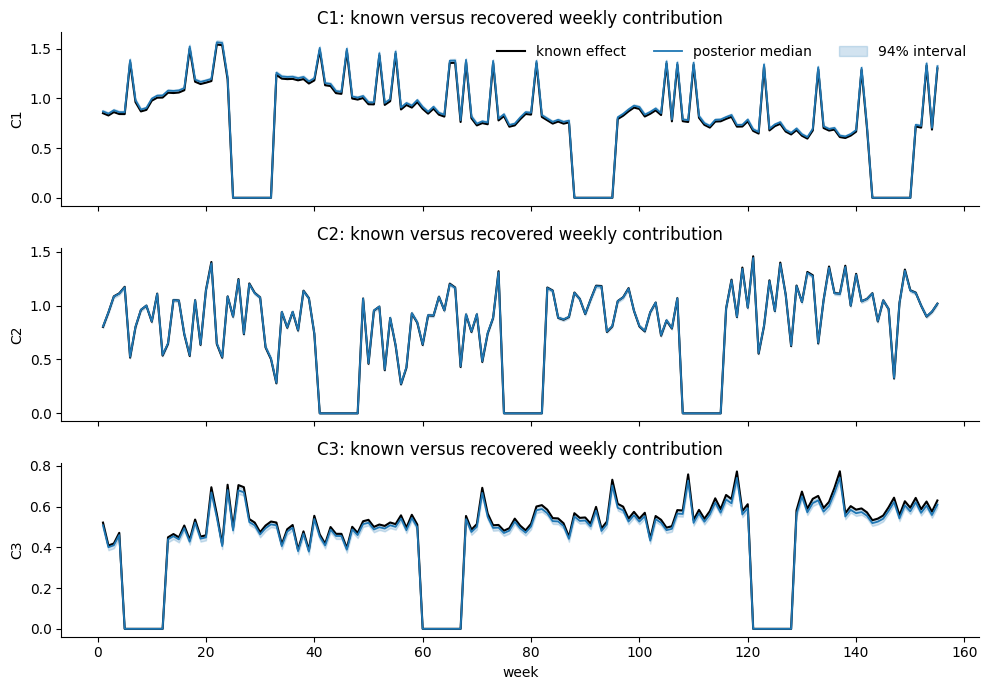

In [11]:
channel_quantiles = channel_samples.quantile(
    [0.03, 0.5, 0.97], dim=('chain', 'draw')
)
scored_weeks = weeks[RECOVERY_START:]
fig, axes = plt.subplots(world.K, 1, figsize=(10, 7), sharex=True)
for k, (ax, name) in enumerate(zip(axes, CHANNEL_COLUMNS, strict=True)):
    true_effect = world.data['contributions_observed'][RECOVERY_START:, k]
    channel_curve = channel_quantiles.sel(channel=name).isel(
        date=slice(RECOVERY_START, None)
    )
    low = channel_curve.sel(quantile=0.03)
    median = channel_curve.sel(quantile=0.5)
    high = channel_curve.sel(quantile=0.97)
    ax.plot(scored_weeks, true_effect, color='black', lw=1.5, label='known effect')
    ax.plot(scored_weeks, median, color='C0', lw=1.3, label='posterior median')
    ax.fill_between(
        scored_weeks, low, high, color='C0', alpha=0.2, label='94% interval'
    )
    ax.set(ylabel=name, title=f'{name}: known versus recovered weekly contribution')
    ax.spines[['top', 'right']].set_visible(False)
axes[0].legend(frameon=False, ncol=3)
axes[-1].set_xlabel('week')
fig.tight_layout()
plt.show()

### Interpretation of the executed recovery check

The committed run returns `PASS`: all four chains complete with no divergences, every posterior-median cumulative channel contribution is within 10% of truth, and every weekly contribution path clears the correlation and normalized-RMSE gates printed above. The table also keeps the 94% interval indicator visible as a stricter uncertainty-calibration diagnostic; it is not substituted for the explicit practical recovery gate.

This result depends on the stated easy-design contract. The graph satisfies back-door adjustment, every channel has observed zero-spend periods, the baseline drift is small, and one-lag adstock prevents unobserved carryover from crossing those interventions. A simple DAG alone would not guarantee finite-sample recovery; the overlap and noise conditions are part of what `easy` means here.

## Generate both corpora

`sample_prior_predictive` is the corpus API and creates padded variable-size tasks. The single full-size world above used `sample_scm` only for its convenient visual API.

In [12]:
easy = pg.sample_prior_predictive(easy_cfg)
hard = pg.sample_prior_predictive(hard_cfg)
assert np.array_equal(easy['g'], hard['g'])
assert np.array_equal(easy['adstock_family'], hard['adstock_family'])
for name, corpus in [('easy', easy), ('difficult', hard)]:
    errors = DataGenerator.validate_corpus(corpus)
    assert errors == [], errors
    print(f'{name}: N={len(corpus["sales_raw"])} elapsed={corpus["diagnostics"]["elapsed_s"]:.2f}s')

easy: N=6 elapsed=17.16s
difficult: N=6 elapsed=17.10s


## Read the active masks

Prefix masks identify active slots. The table shows observed cells with channels and controls switched off by padding.

In [13]:
def count_table(corpus):
    return [
        (int(corpus['cell_id'][i]), int(corpus['K_active'][i]), int(corpus['M_active'][i]),
         ''.join(map(str, corpus['active_c_mask'][i])),
         ''.join(map(str, corpus['active_m_mask'][i])))
        for i in range(len(corpus['cell_id']))
    ]

print('cell  K  M  active_C  active_Z')
for row in count_table(easy):
    print(f'{row[0]:>4} {row[1]:>2} {row[2]:>2} {row[3]:>9} {row[4]:>9}')
assert np.any(easy['K_active'] < 3) and np.any(easy['M_active'] < 2)
assert np.all(easy['spend_raw'] * (1 - easy['active_c_mask'][:, None, :]) == 0)
assert np.all(easy['controls'] * (1 - easy['active_m_mask'][:, None, :]) == 0)

cell  K  M  active_C  active_Z
   0  1  2       100        11
   1  1  1       100        10
   2  3  1       111        10
   3  3  1       111        10
   4  1  2       100        11
   5  2  1       110        10


## Audit every graph and padded mechanism field

The latent demand node is active only as a padded-layout convention: it has no incident edges and its contributions are exactly zero.

In [14]:
def assert_simple_corpus(corpus, cfg):
    layout = SlotLayout(3, 2, 1, edge_types=cfg.layout.edge_types)
    blocks = layout.unpack(corpus['g'])
    c_mask, m_mask, j_mask = (corpus['active_c_mask'], corpus['active_m_mask'], corpus['active_j_mask'])
    assert np.array_equal(c_mask, np.arange(3)[None, :] < corpus['K_active'][:, None])
    assert np.array_equal(m_mask, np.arange(2)[None, :] < corpus['M_active'][:, None])
    assert np.array_equal(j_mask, np.ones((len(c_mask), 1), dtype=np.uint8))
    assert np.all(corpus['J_active'] == 1)
    assert not blocks['dc'].any() and not blocks['dz'].any() and not blocks['db'].any()
    assert not blocks['zc'].any() and not blocks['cc'].any() and not blocks['zz'].any()
    assert np.array_equal(blocks['cy'], c_mask)
    assert np.array_equal(blocks['zb'], m_mask)
    active_adstock = np.take(ADSTOCK_FAMILY_KEYS, corpus['adstock_family'][c_mask.astype(bool)])
    inactive_adstock = np.take(ADSTOCK_FAMILY_KEYS, corpus['adstock_family'][~c_mask.astype(bool)])
    assert np.all(active_adstock == 'geometric')
    assert np.all(inactive_adstock == 'none')
    for key in ('spend_raw', 'contributions_raw', 'channel_level', 'saturation_scale',
                'adstock_alpha', 'weibull_lam', 'weibull_k'):
        values = corpus[key]
        assert np.all(values * (1 - c_mask[:, None, :] if values.ndim == 3 else 1 - c_mask) == 0), key
    assert np.all(corpus['controls'] * (1 - m_mask[:, None, :]) == 0)
    assert np.all(corpus['demand'] * (1 - j_mask[:, None, :]) == 0)
    assert np.all(corpus['confounder_contribution'] == 0)
    assert np.all(corpus['confounding_strength'] == 0)
    assert np.all(corpus['indirect_effects'] == 0)
    assert np.all(corpus['indirect_effects_by_source'] == 0)
    additive = corpus['baseline_raw'] + corpus['contributions_raw'].sum(-1) + corpus['indirect_effects']
    full = (corpus['baseline_intrinsic'] + corpus['confounder_contribution'].sum(-1) +
            corpus['control_contribution'].sum(-1) +
            corpus['contributions_raw'].sum(-1) + corpus['indirect_effects_by_source'].sum(-1))
    assert np.allclose(corpus['sales_raw'], additive, atol=2e-6)
    assert np.allclose(corpus['sales_raw'], full, atol=2e-6)
    assert np.allclose(corpus['indirect_effects'], corpus['indirect_effects_by_source'].sum(-1), atol=2e-6)

assert_simple_corpus(easy, easy_cfg)
assert_simple_corpus(hard, hard_cfg)
print('all graph, padding, isolation, and decomposition assertions passed')

all graph, padding, isolation, and decomposition assertions passed


## Family audit

The corpus persists active-channel `adstock_family` values, but its unchanged schema does not persist `sat_family`. The named configuration and the public audit of the single sampled world establish the selected Michaelis-Menten saturation without relying on a memorized categorical order.

In [15]:
active_adstock = np.take(ADSTOCK_FAMILY_KEYS, easy['adstock_family'][easy['active_c_mask'].astype(bool)])
assert set(active_adstock) == {'geometric'}
assert easy_cfg.adstock_family_probs['geometric'] == 1.0
assert easy_cfg.saturation_family_probs['michaelis_menten'] == 1.0
print('corpus active-channel adstock:', sorted(set(active_adstock)))
print('single-world saturation audit: Michaelis-Menten (shown above)')

corpus active-channel adstock: [np.str_('geometric')]
single-world saturation audit: Michaelis-Menten (shown above)


## Easy versus difficult: a noise diagnostic

The statistic below is the standard deviation of the persisted intrinsic baseline after the control and latent baseline terms have been removed. In this configuration the latent term is exactly zero. The intrinsic baseline contains the baseline walk and the observed-sales noise walk, so changing only `rw_sales_std_sigma` should increase this diagnostic. It is a generator diagnostic, not a causal estimator. The existing signal labels describe channel-target texture, so they are reported only as supplementary context.

In [16]:
def noise_summary(corpus):
    signal = corpus['identifiability']['signal_metrics']
    valid = corpus['identifiability']['signal_metric_valid'].astype(bool)
    spearman_index = pg.SIGNAL_METRIC_LAYOUT.index('spearman')
    intrinsic_std = corpus['baseline_intrinsic'].std(axis=1).mean()
    return float(intrinsic_std), float(signal[..., spearman_index][valid[..., spearman_index]].mean())

easy_noise, easy_spearman = noise_summary(easy)
hard_noise, hard_spearman = noise_summary(hard)
print('variant    rw_sales_std_sigma  intrinsic_std  mean signal spearman')
print(f'easy       {easy_cfg.rw_sales_std_sigma:>18.2f}  {easy_noise:>12.4f}  {easy_spearman:>20.4f}')
print(f'difficult  {hard_cfg.rw_sales_std_sigma:>18.2f}  {hard_noise:>12.4f}  {hard_spearman:>20.4f}')
assert hard_noise > easy_noise
print(f'intrinsic-baseline ratio: {hard_noise / easy_noise:.1f}x')

variant    rw_sales_std_sigma  intrinsic_std  mean signal spearman
easy                     0.03        0.0237                1.0000
difficult                1.00        0.8207                1.0000
intrinsic-baseline ratio: 34.7x


The rows below are paired by the shared seed, cell, and draw order. The assertions verify that their graph, spend, and controls are identical, so the displayed sales and baseline difference is attributable to the only changed generator knob: `rw_sales_std_sigma`.

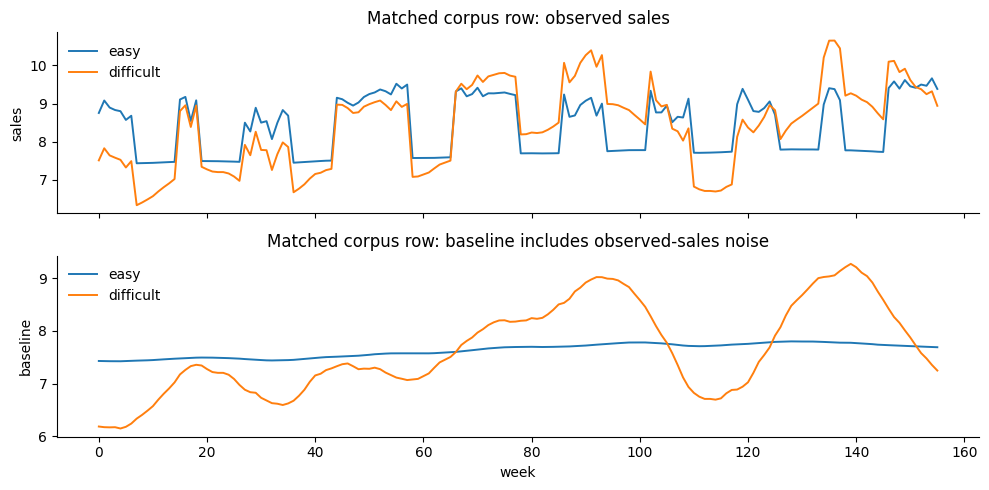

In [17]:
row = 0
assert np.array_equal(easy['g'][row], hard['g'][row])
assert np.array_equal(easy['spend_raw'][row], hard['spend_raw'][row])
assert np.array_equal(easy['controls'][row], hard['controls'][row])
assert np.array_equal(easy['contributions_raw'][row], hard['contributions_raw'][row])
weeks = np.arange(easy_cfg.T)
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for corpus, label in ((easy, 'easy'), (hard, 'difficult')):
    axes[0].plot(weeks, corpus['sales_raw'][row], lw=1.4, label=label)
    axes[1].plot(weeks, corpus['baseline_raw'][row], lw=1.4, label=label)
axes[0].set(title='Matched corpus row: observed sales', ylabel='sales')
axes[1].set(title='Matched corpus row: baseline includes observed-sales noise', xlabel='week', ylabel='baseline')
for ax in axes:
    ax.legend(frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## Recap

This is a small, reproducible padded corpus with a controlled graph and mechanism family. Increasing only `rw_sales_std_sigma` makes the observed sales path harder without introducing latent or shared baseline-channel confounding.